# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age, fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [2]:
import pandas as pd

df = pd.read_csv('titanic_passengers.csv')

df.head(25)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [3]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
sex_survival = pd.crosstab(
    df['Sex'],
    df['Survived'],
    normalize='index'
)

print(sex_survival)

Survived         0         1
Sex                         
female    0.257962  0.742038
male      0.811092  0.188908


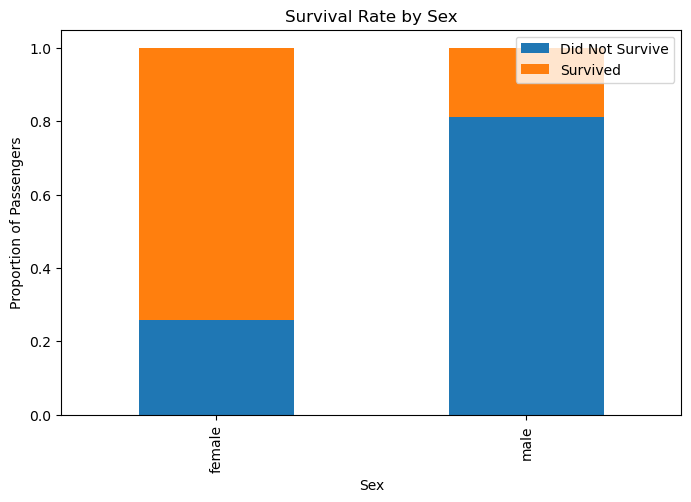

In [6]:
import matplotlib.pyplot as plt

sex_survival.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Proportion of Passengers')
plt.legend(['Did Not Survive', 'Survived'])

plt.show()

Female passengers had a substantially higher survival rate than male passengers. This suggests that sex was one of the strongest factors influencing survival during the Titanic disaster.

In [7]:
pclass_survival = pd.crosstab(
    df['Pclass'],
    df['Survived'],
    normalize='index'
)

print(pclass_survival)

Survived         0         1
Pclass                      
1         0.370370  0.629630
2         0.527174  0.472826
3         0.757637  0.242363


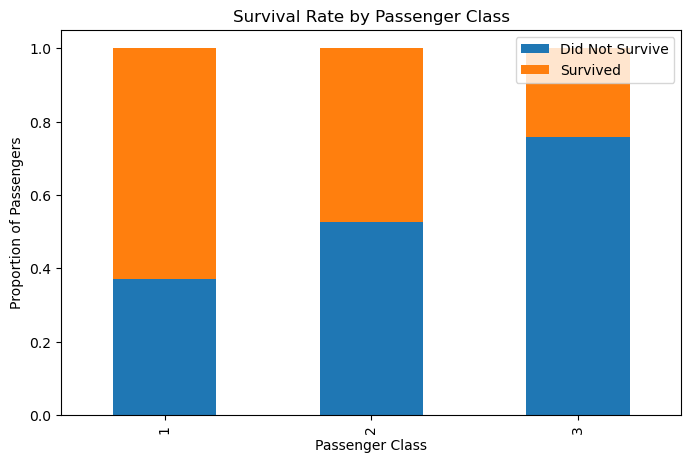

In [8]:
pclass_survival.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Proportion of Passengers')
plt.legend(['Did Not Survive', 'Survived'])

plt.show()

First-class passengers had the highest survival rate, while third-class passengers had the lowest survival rate. This indicates that socioeconomic status played a major role in survival outcomes.

In [9]:
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [11]:
df['Age_Group'] = 'Unknown'

df.loc[df['Age'] < 18, 'Age_Group'] = 'Child'

df.loc[
    (df['Age'] >= 18) &
    (df['Age'] < 60),
    'Age_Group'
] = 'Adult'

df.loc[df['Age'] >= 60, 'Age_Group'] = 'Senior'

In [12]:
age_survival = pd.crosstab(
    df['Age_Group'],
    df['Survived'],
    normalize='index'
)

print(age_survival)

Survived          0         1
Age_Group                    
Adult      0.613913  0.386087
Child      0.460177  0.539823
Senior     0.730769  0.269231
Unknown    0.706215  0.293785


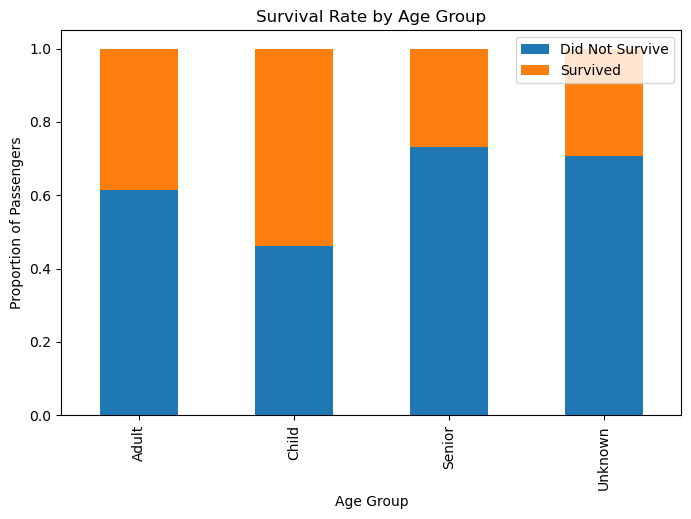

In [13]:
age_survival.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Proportion of Passengers')
plt.legend(['Did Not Survive', 'Survived'])

plt.show()

Survived         0         1
SibSp                       
0         0.654605  0.345395
1         0.464115  0.535885
2         0.535714  0.464286
3         0.750000  0.250000
4         0.833333  0.166667
5         1.000000  0.000000
8         1.000000  0.000000


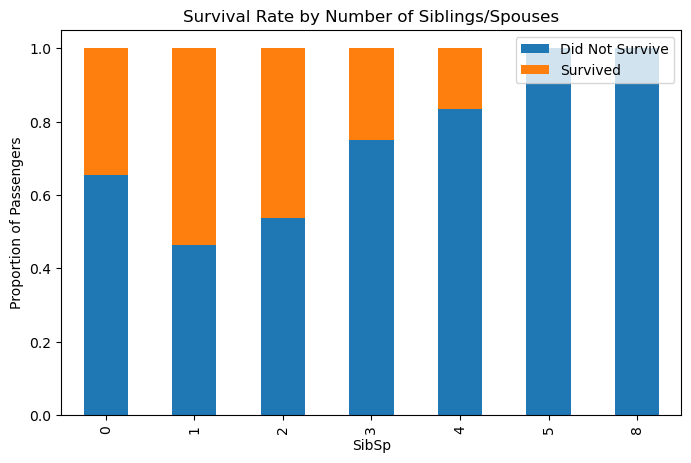

In [17]:
sibsp_survival = pd.crosstab(
    df['SibSp'],
    df['Survived'],
    normalize='index'
)

print(sibsp_survival)

sibsp_survival.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Survival Rate by Number of Siblings/Spouses')
plt.xlabel('SibSp')
plt.ylabel('Proportion of Passengers')
plt.legend(['Did Not Survive', 'Survived'])

plt.show()

Survived         0         1
Parch                       
0         0.656342  0.343658
1         0.449153  0.550847
2         0.500000  0.500000
3         0.400000  0.600000
4         1.000000  0.000000
5         0.800000  0.200000
6         1.000000  0.000000


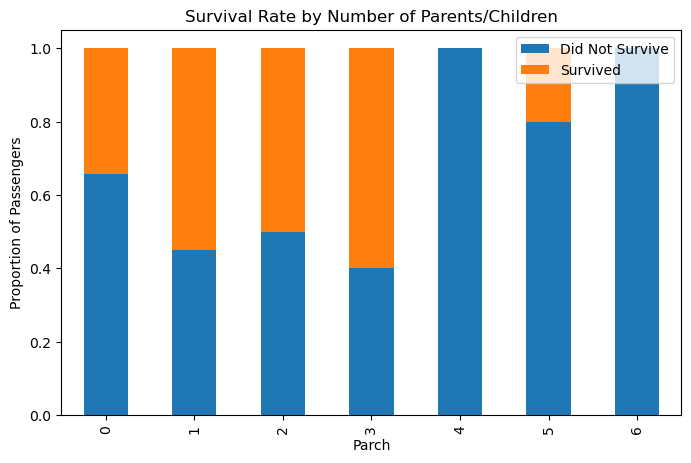

In [18]:
parch_survival = pd.crosstab(
    df['Parch'],
    df['Survived'],
    normalize='index'
)

print(parch_survival)

parch_survival.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Survival Rate by Number of Parents/Children')
plt.xlabel('Parch')
plt.ylabel('Proportion of Passengers')
plt.legend(['Did Not Survive', 'Survived'])

plt.show()

Survived         0         1
Embarked                    
C         0.446429  0.553571
Q         0.610390  0.389610
S         0.663043  0.336957


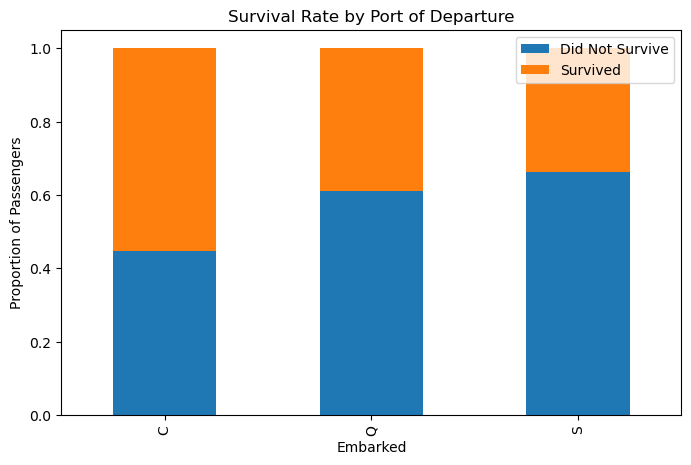

In [19]:
embarked_survival = pd.crosstab(
    df['Embarked'],
    df['Survived'],
    normalize='index'
)

print(embarked_survival)

embarked_survival.plot(
    kind='bar',
    stacked=True,
    figsize=(8,5)
)

plt.title('Survival Rate by Port of Departure')
plt.xlabel('Embarked')
plt.ylabel('Proportion of Passengers')
plt.legend(['Did Not Survive', 'Survived'])

plt.show()

In [22]:
df['Fare_Group'] = 'Unknown'

df.loc[df['Fare'] < 7.91, 'Fare_Group'] = 'Low Fare'

df.loc[
    (df['Fare'] >= 7.91) &
    (df['Fare'] < 14.45),
    'Fare_Group'
] = 'Medium Fare'

df.loc[
    (df['Fare'] >= 14.45) &
    (df['Fare'] < 31.00),
    'Fare_Group'
] = 'High Fare'

df.loc[
    df['Fare'] >= 31.00,
    'Fare_Group'
] = 'Very High Fare'

In [23]:
# Sex
sex_survival = pd.crosstab(
    df['Sex'],
    df['Survived'],
    normalize='index'
)

# Pclass
pclass_survival = pd.crosstab(
    df['Pclass'],
    df['Survived'],
    normalize='index'
)

# Age Group
age_survival = pd.crosstab(
    df['Age_Group'],
    df['Survived'],
    normalize='index'
)

# Fare Group
fare_survival = pd.crosstab(
    df['Fare_Group'],
    df['Survived'],
    normalize='index'
)

# SibSp
sibsp_survival = pd.crosstab(
    df['SibSp'],
    df['Survived'],
    normalize='index'
)

# Parch
parch_survival = pd.crosstab(
    df['Parch'],
    df['Survived'],
    normalize='index'
)

# Embarked
embarked_survival = pd.crosstab(
    df['Embarked'],
    df['Survived'],
    normalize='index'
)

print("====================================")
print("SEX SURVIVAL")
print("====================================")
print(sex_survival)

print("\n====================================")
print("PASSENGER CLASS SURVIVAL")
print("====================================")
print(pclass_survival)

print("\n====================================")
print("AGE GROUP SURVIVAL")
print("====================================")
print(age_survival)

print("\n====================================")
print("FARE GROUP SURVIVAL")
print("====================================")
print(fare_survival)

print("\n====================================")
print("SIBSP SURVIVAL")
print("====================================")
print(sibsp_survival)

print("\n====================================")
print("PARCH SURVIVAL")
print("====================================")
print(parch_survival)

print("\n====================================")
print("EMBARKED SURVIVAL")
print("====================================")
print(embarked_survival)

SEX SURVIVAL
Survived         0         1
Sex                         
female    0.257962  0.742038
male      0.811092  0.188908

PASSENGER CLASS SURVIVAL
Survived         0         1
Pclass                      
1         0.370370  0.629630
2         0.527174  0.472826
3         0.757637  0.242363

AGE GROUP SURVIVAL
Survived          0         1
Age_Group                    
Adult      0.613913  0.386087
Child      0.460177  0.539823
Senior     0.730769  0.269231
Unknown    0.706215  0.293785

FARE GROUP SURVIVAL
Survived               0         1
Fare_Group                        
High Fare       0.557522  0.442478
Low Fare        0.802691  0.197309
Medium Fare     0.691244  0.308756
Very High Fare  0.417778  0.582222

SIBSP SURVIVAL
Survived         0         1
SibSp                       
0         0.654605  0.345395
1         0.464115  0.535885
2         0.535714  0.464286
3         0.750000  0.250000
4         0.833333  0.166667
5         1.000000  0.000000
8         1.000000  0

In [24]:
most_likely = df[
    (df['Sex'] == 'female') &
    (df['Pclass'] == 1) &
    (df['Embarked'] == 'C')
]

most_likely[['Name', 'Age', 'Fare', 'SibSp', 'Parch']].head(20)

,Name,Age,Fare,SibSp,Parch
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,71.2833,1,0
31,"Spencer, Mrs. William Augustus (Marie Eugenie)",NaN,146.5208,1,0
52,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",49.0,76.7292,1,0
177,"Isham, Miss. Ann Elizabeth",50.0,28.7125,0,0
194,"Brown, Mrs. James Joseph (Margaret Tobin)",44.0,27.7208,0,0
195,"Lurette, Miss. Elise",58.0,146.5208,0,0
215,"Newell, Miss. Madeleine",31.0,113.2750,1,0
218,"Bazzani, Miss. Albina",32.0,76.2917,0,0
256,"Thorne, Mrs. Gertrude Maybelle",NaN,79.2000,0,0
258,"Ward, Miss. Anna",35.0,512.3292,0,0


In [25]:
least_likely = df[
    (df['Sex'] == 'male') &
    (df['Pclass'] == 3) &
    (df['Embarked'] == 'S')
]

least_likely[['Name', 'Age', 'Fare', 'SibSp', 'Parch']].head(20)

,Name,Age,Fare,SibSp,Parch
0,"Braund, Mr. Owen Harris",22.0,7.2500,1,0
4,"Allen, Mr. William Henry",35.0,8.0500,0,0
7,"Palsson, Master. Gosta Leonard",2.0,21.0750,3,1
12,"Saundercock, Mr. William Henry",20.0,8.0500,0,0
13,"Andersson, Mr. Anders Johan",39.0,31.2750,1,5
29,"Todoroff, Mr. Lalio",NaN,7.8958,0,0
37,"Cann, Mr. Ernest Charles",21.0,8.0500,0,0
45,"Rogers, Mr. William John",NaN,8.0500,0,0
50,"Panula, Master. Juha Niilo",7.0,39.6875,4,1
51,"Nosworthy, Mr. Richard Cater",21.0,7.8000,0,0
